In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Advertising.csv", index_col= 0)
print("set up complete")

set up complete


In [2]:
df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


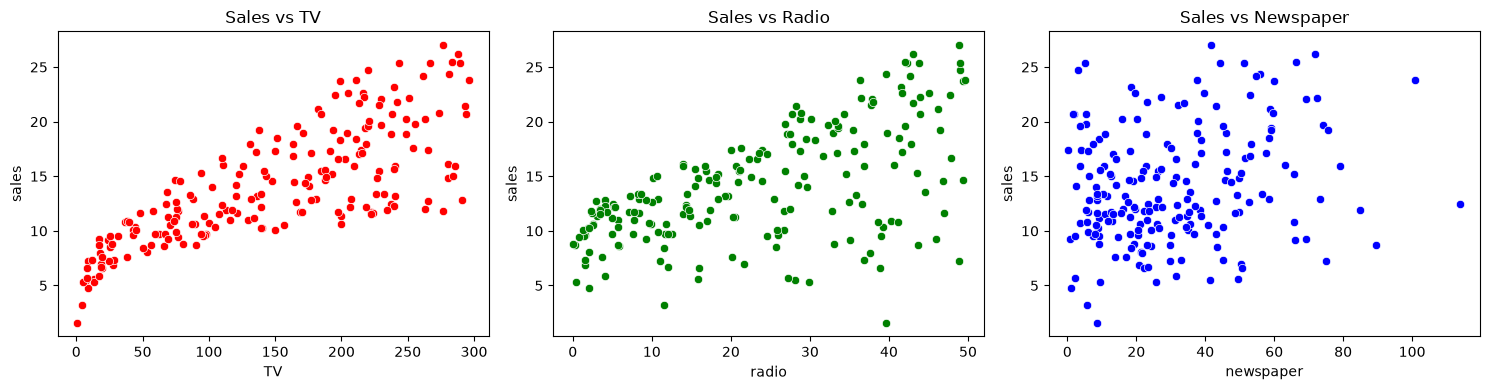

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sales vs TV
sns.scatterplot(
    data=df,
    x="TV",
    y="sales",
    color="red",
    ax=axes[0]
)
axes[0].set_title("Sales vs TV")

# Sales vs Radio
sns.scatterplot(
    data=df,
    x="radio",
    y="sales",
    color="green",
    ax=axes[1]
)
axes[1].set_title("Sales vs Radio")

# Sales vs Newspaper
sns.scatterplot(
    data=df,
    x="newspaper",
    y="sales",
    color="blue",
    ax=axes[2]
)
axes[2].set_title("Sales vs Newspaper")

plt.tight_layout()
plt.show()

The first plot shows a sharp upward trend in the number of units sold as TV advertising increases. A similar trend is also found as radio advertising increases. However, in the last plot, there does not appear to be a relationship between newspaper advertising and the number of units sold.

--

$$\hat{\beta_1} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

$$\hat{\beta_0} = \bar{y} - \beta_1\bar{x}$$
From the samples provided, first we find $\beta_1$ from the first expression and substitute the value of $\beta_1$ in the second expression for $\beta_0$.

In [5]:
X = df.TV.to_numpy()
y = df.sales.to_numpy()

In [6]:
# Calculating beta_1
x_mean = X.mean()
y_mean = y.mean()

beta_1 = np.sum(
    (X - x_mean) * (y - y_mean)
) / np.sum(
    np.power(
        (X - x_mean),
         2
    )
)

print(beta_1)

0.047536640433019736


In [7]:
# Calculating beta_0
beta_0 = y_mean - (beta_1 * x_mean)

print(beta_0)

7.0325935491276965


In [8]:
# Best Fit Line Equation
print(f"y= {beta_0:.3f} + {beta_1:.3f} x")

y= 7.033 + 0.048 x


In [9]:
# Calculating SSE
y_hat = beta_0 + (beta_1 * X)

SSE = np.sum(
    np.power(
        (y - y_hat), 
        2
    )
)

print(SSE)

2102.5305831313512


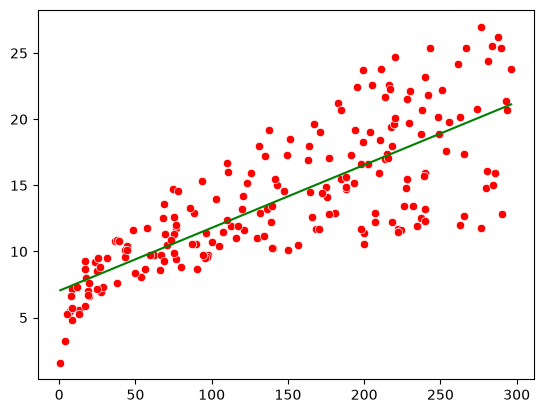

In [11]:
sns.scatterplot(
    x=X,
    y=y,
    color="red"
)

sns.lineplot(
    x=X,
    y=beta_0 + (beta_1 * X),
    color="green"
)

plt.show()

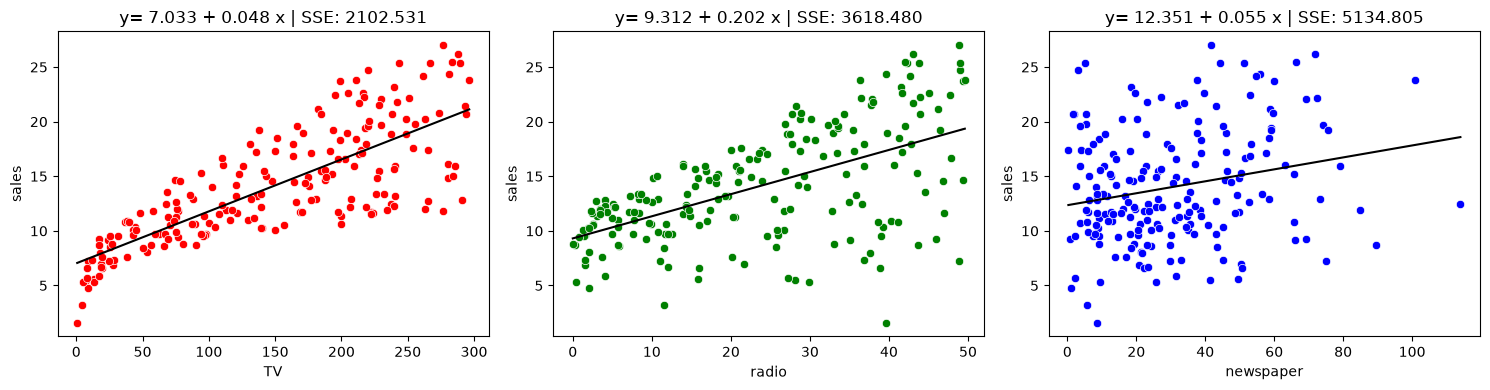

In [15]:
fig, axes = plt.subplots(
    1, 
    3,
    figsize= (15, 4)
)

def train_plot(df, feature, ax, c):
    X = df[feature].to_numpy()
    y = df.sales.to_numpy()

    # Calculating beta_1
    x_mean = X.mean()
    y_mean = y.mean()

    beta_1 = np.sum(
        (X - x_mean) * (y - y_mean)
    ) / np.sum(
        np.power(
            (X - x_mean),
            2
        )
    )

    # Calculating beta_0
    beta_0 = y_mean - (beta_1 * x_mean)

    # Predicted values
    y_hat = beta_0 + np.dot(
        X,
        beta_1
    )

    # SSE
    SSE = np.sum(
        np.power(
            (y - y_hat),
            2
        )
    )

    # Plot
    sns.scatterplot(
        x= X,
        y= y,
        color= c,
        ax= ax
    )

    sns.lineplot(
        x= X,
        y= y_hat,
        color= 'black',
        ax= ax
    )


    ax.set_xlabel(feature)
    ax.set_ylabel('sales')
    ax.set_title(
        f"y= {beta_0:.3f} + {beta_1:.3f} x | SSE: {SSE:.3f}"
    )

# TV
train_plot(
    df,
    'TV',
    axes[0],
    'red'
)

# Radio
train_plot(
    df,
    'radio',
    axes[1],
    'green'
)

# Newspaper
train_plot(
    df,
    'newspaper',
    axes[2],
    'blue'
)

plt.tight_layout()
plt.show()